# Análise Exploratória de Dados: Doenças Cardíacas (UCI Heart Disease)

Este notebook apresenta uma análise exploratória detalhada da base de dados de doenças cardíacas da UCI. 
O objetivo é investigar a qualidade dos dados, identificar valores ausentes (incluindo os disfarçados) e visualizar padrões importantes.

### Estrutura dos Dados:
- **age**: Idade em anos
- **sex**: Sexo (Male/Female)
- **dataset**: Local da coleta
- **cp**: Tipo de dor no peito
- **trestbps**: Pressão arterial em repouso
- **chol**: Colesterol sérico em mg/dl
- **fbs**: Açúcar no sangue em jejum > 120 mg/dl
- **restecg**: Resultados eletrocardiográficos em repouso
- **thalch**: Frequência cardíaca máxima atingida
- **exang**: Angina induzida por exercício
- **oldpeak**: Depressão de ST induzida pelo exercício em relação ao repouso
- **slope**: A inclinação do segmento ST de pico do exercício
- **ca**: Número de vasos principais coloridos por fluoroscopia
- **thal**: Tipo de defeito (normal, fixed defect, reversable defect)
- **num**: Diagnóstico de doença cardíaca (valor alvo)


In [64]:
import eda_utils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [49]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_seq_items', None)

In [50]:
df = pd.read_csv('data/heart_disease_uci.csv')

eda_utils.info_geral(df)

DIMENSÕES
Linhas: 920
Colunas: 16

TIPOS DAS VARIÁVEIS
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

MEMÓRIA USADA
Index         132
id           7360
age          7360
sex         49148
dataset     53820
cp          56530
trestbps     7360
chol         7360
fbs         32760
restecg     53848
thalch       7360
exang       32900
oldpeak      7360
slope       43727
ca           7360
thal        41810
num          7360
dtype: int64


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [52]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [53]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [54]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_analysis = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percentage})
print(missing_analysis)

          Missing Count  Missing Percentage
id                    0            0.000000
age                   0            0.000000
sex                   0            0.000000
dataset               0            0.000000
cp                    0            0.000000
trestbps             59            6.413043
chol                 30            3.260870
fbs                  90            9.782609
restecg               2            0.217391
thalch               55            5.978261
exang                55            5.978261
oldpeak              62            6.739130
slope               309           33.586957
ca                  611           66.413043
thal                486           52.826087
num                   0            0.000000


# Análise de Valores Ausentes - Heart Disease UCI

## Resumo Geral
O dataset possui **920 linhas** e apresenta **valores ausentes em 10 das 16 colunas**, totalizando **1.799 registros faltantes** distribuídos de forma não uniforme.

## Distribuição de Ausências por Coluna

### Colunas Sem Ausências (Completas)
- **id**: 0 valores ausentes
- **age**: 0 valores ausentes
- **sex**: 0 valores ausentes
- **dataset**: 0 valores ausentes
- **cp**: 0 valores ausentes
- **num**: 0 valores ausentes

Essas 6 colunas possuem informações completas e não exigem imputação.

### Colunas com Baixa Taxa de Ausência (<5%)
- **chol**: 30 ausentes (~3,3%)
- **restecg**: 2 ausentes (~0,2%)

Essas variáveis apresentam ausências mínimas e podem ser tratadas com imputação simples.

### Colunas com Ausência Moderada (5-10%)
- **trestbps**: 59 ausentes (~6,4%)
- **thalch**: 55 ausentes (~6,0%)
- **exang**: 55 ausentes (~6,0%)
- **oldpeak**: 62 ausentes (~6,7%)
- **fbs**: 90 ausentes (~9,8%)

Essas colunas possuem ausências moderadas, viáveis para imputação por média, mediana ou modelagem.

### Colunas com Alta Taxa de Ausência (>15%)
- **slope**: 309 ausentes (~33,6%)
- **ca**: 611 ausentes (~66,4%)
- **thal**: 486 ausentes (~52,8%)

Estas três colunas apresentam **ausências significativas**:
  - **ca** possui mais de 66% dos dados faltantes - **deve ser descartada**
  - **thal** possui mais de 52% dos dados faltantes - **deve ser descartada**
  - **slope** possui mais de 33% dos dados faltantes - **considerar descarte ou análise aprofundada**

## Recomendações
1. **Descartar**: `ca` e `thal` devido à alta taxa de ausência (>50%)
2. **Investigar**: `slope` para entender o padrão de ausência e decidir se mantém ou descarta
3. **Imputar**: As demais colunas com estratégias apropriadas (média, mediana, KNN, etc.)
4. **Validar**: Verificar se a ausência é aleatória (MCAR) ou possui padrão associado aos dados

In [55]:
print(df.isnull().mean()*100)

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


In [56]:
df.duplicated().sum()  

np.int64(0)

In [57]:
for col in df.columns:
        print(f"{col}: {df[col].nunique()} valores únicos")

id: 920 valores únicos
age: 50 valores únicos
sex: 2 valores únicos
dataset: 4 valores únicos
cp: 4 valores únicos
trestbps: 61 valores únicos
chol: 217 valores únicos
fbs: 2 valores únicos
restecg: 3 valores únicos
thalch: 119 valores únicos
exang: 2 valores únicos
oldpeak: 53 valores únicos
slope: 3 valores únicos
ca: 4 valores únicos
thal: 3 valores únicos
num: 5 valores únicos


In [58]:
from IPython.display import display

def valores_unicos_baixa_cardinalidade(
    df,
    limite=10
):

    for col in df.columns:

        n_unicos = df[col].nunique()

        if n_unicos < limite:

            print("="*50)
            print(f"{col} ({n_unicos} valores)")
            print("="*50)

            print("Valores únicos:")
            print(
                sorted(
                    df[col]
                    .dropna()
                    .unique()
                    .tolist()
                )
            )

            print("\nContagem:")

            display(
                df[col]
                .value_counts()
                .sort_index()
                .to_frame(
                    name="frequencia"
                )
            )

In [59]:
valores_unicos_baixa_cardinalidade(df)

sex (2 valores)
Valores únicos:
['Female', 'Male']

Contagem:


,frequencia
sex,
Female,194
Male,726


dataset (4 valores)
Valores únicos:
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']

Contagem:


,frequencia
dataset,
Cleveland,304
Hungary,293
Switzerland,123
VA Long Beach,200


cp (4 valores)
Valores únicos:
['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina']

Contagem:


...

,frequencia
ca,
0.0,181
1.0,67
2.0,41
3.0,20


thal (3 valores)
Valores únicos:
['fixed defect', 'normal', 'reversable defect']

Contagem:


,frequencia
thal,
fixed defect,46
normal,196
reversable defect,192


num (5 valores)
Valores únicos:
[0, 1, 2, 3, 4]

Contagem:


,frequencia
num,
0,411
1,265
2,109
3,107
4,28


# Análise de Variáveis de Baixa Cardinalidade - Heart Disease UCI

## Resumo Geral
O dataset contém **10 variáveis com baixa cardinalidade** (<10 valores únicos), sendo a maioria variáveis categóricas, binárias ou ordinais. Essas variáveis são relevantes para a modelagem preditiva e para compreensão clínica dos dados.

Além disso, foram identificados padrões relevantes de **desbalanceamento**, **ausência de dados** e possível **heterogeneidade entre centros**, que devem ser considerados antes da modelagem.

---

## Variáveis Categóricas Binárias

### sex (2 valores)
Distribuição de gênero dos pacientes:

- **Female**: 194 pacientes (21.1%)
- **Male**: 726 pacientes (78.9%)

**Observação:** O dataset apresenta predominância masculina (aproximadamente 4:1 em relação a mulheres), o que pode introduzir viés e limitar a generalização do modelo para pacientes do sexo feminino.

---

### fbs (2 valores)
Nível de glicose em jejum >120 mg/dl:

- **False**: 692 pacientes (75.2%) — Nível normal  
- **True**: 138 pacientes (24.8%) — Nível elevado  

**Observação:** A maioria dos pacientes apresenta glicemia em jejum normal.

---

### exang (2 valores)
Angina induzida por exercício:

- **False**: 528 pacientes (57.4%) — Sem angina induzida  
- **True**: 337 pacientes (42.6%) — Com angina induzida  

**Observação:** Distribuição relativamente equilibrada entre pacientes com e sem angina induzida.

---

## Variáveis Categóricas Nominais

### dataset (4 valores)
Origem geográfica dos dados:

- **Cleveland**: 304 pacientes (33.0%)  
- **Hungary**: 293 pacientes (31.8%)  
- **Switzerland**: 123 pacientes (13.4%)  
- **VA Long Beach**: 200 pacientes (21.7%)

**Observação:** Os dados foram coletados em quatro centros distintos. Isso pode introduzir efeito de centro e heterogeneidade populacional.

---

### cp (4 valores)
Tipo de dor no peito:

- **asymptomatic**: 496 pacientes (53.9%)  
- **atypical angina**: 174 pacientes (18.9%)  
- **non-anginal**: 204 pacientes (22.2%)  
- **typical angina**: 46 pacientes (5.0%)

**Observação:** A categoria assintomática predomina. Angina típica é rara.

---

### restecg (3 valores)
Resultados do eletrocardiograma em repouso:

- **normal**: 551 pacientes (59.9%)  
- **lv hypertrophy**: 188 pacientes (20.4%)  
- **st-t abnormality**: 179 pacientes (19.5%)

**Observação:** A maioria apresenta ECG normal, mas aproximadamente 40% possui alguma anormalidade.

---

### slope (3 valores)
Inclinação do segmento ST:

- **flat**: 345 pacientes (37.5%)  
- **upsloping**: 203 pacientes (22.1%)  
- **downsloping**: 63 pacientes (6.8%)

**Observação:** Inclinação plana é a mais frequente.

**Alerta:** 309 valores ausentes (33.6%).

---

## Variáveis Ordinais/Clínicas

### ca (4 valores)
Número de vasos principais com estenose:

- **0.0**: 181 pacientes (19.7%)  
- **1.0**: 67 pacientes (7.3%)  
- **2.0**: 41 pacientes (4.5%)  
- **3.0**: 20 pacientes (2.2%)

**Observação:** A distribuição concentra-se em pacientes sem vasos com estenose detectável.

**Alerta:** 611 valores ausentes (66.4%).

---

### thal (3 valores)
Tipo de defeito talassêmico:

- **normal**: 196 pacientes (21.3%)  
- **fixed defect**: 46 pacientes (5.0%)  
- **reversable defect**: 192 pacientes (20.9%)

**Observação:** Há distribuição relativamente equilibrada entre normal e defeito reversível.

**Alerta:** 486 valores ausentes (52.8%).

---

## Variável-Alvo

### num (5 valores)
Presença e severidade de doença cardíaca:

- **0**: 411 pacientes (44.7%) — Sem doença  
- **1**: 265 pacientes (28.8%) — Doença leve  
- **2**: 109 pacientes (11.8%) — Doença moderada  
- **3**: 107 pacientes (11.6%) — Doença severa  
- **4**: 28 pacientes (3.0%) — Doença muito severa

### Interpretação
A variável possui **natureza ordinal**, com:

```text
0 < 1 < 2 < 3 < 4
```

Portanto, além de classificação multiclasse convencional, existe possibilidade de modelagem ordinal.

---

### Balanceamento do alvo

### Formulação multiclasse
Existe desbalanceamento, especialmente na classe 4 (apenas 3%).

---

### Formulação binária (presença vs ausência)
Agrupando:

- Sem doença (`num = 0`): 411 casos  
- Com doença (`num > 0`): 509 casos

A distribuição torna-se relativamente equilibrada:

- 44.7% vs 55.3%

**Observação:** Para classificação binária, o desbalanceamento deixa de ser uma preocupação relevante.

---

## Ausência de Dados

Foi identificado padrão importante de valores ausentes em:

| Variável | Missing |
|--------|---------|
| slope | 33.6% |
| thal | 52.8% |
| ca | 66.4% |

### Observação metodológica
Os padrões observados sugerem que os dados faltantes podem **não ser completamente aleatórios (MCAR)**, exigindo cautela em estratégias simples de imputação.

Essas ausências podem estar associadas:
- ao centro de origem (`dataset`)
- à gravidade da doença (`num`)
- à não realização de exames específicos

---

## Principais Pontos de Atenção

- Predominância masculina pode gerar viés.
- `ca` e `thal` apresentam altíssimo percentual de ausência.
- A variável-alvo é ordinal.
- O problema pode ser tratado como binário ou multiclasse.
- Há possível efeito de centro (`dataset`).

---

## Recomendações

1. Avaliar o problema tanto como:
   - classificação binária (presença/ausência)
   - classificação ordinal (graus de severidade)

2. Investigar estratégias para `ca`, `thal` e `slope`, comparando:
   - exclusão  
   - imputação  
   - tratamento explícito da ausência

3. Verificar se os dados faltantes estão associados à origem dos centros ou à gravidade da doença.

4. Testar associação entre variáveis categóricas e o alvo (ex.: teste Qui-quadrado).

5. Avaliar possível efeito de centro (`dataset`) e viés por sexo.

6. Caso seja utilizada formulação multiclasse, considerar tratamento das classes raras.

---

## Nota
Percentuais calculados em relação ao total do dataset (n = 920).

In [60]:
for c in df.columns:
    print(c, df[c].nunique())

id 920
age 50
sex 2
dataset 4
cp 4
trestbps 61
chol 217
fbs 2
restecg 3
thalch 119
exang 2
oldpeak 53
slope 3
ca 4
thal 3
num 5


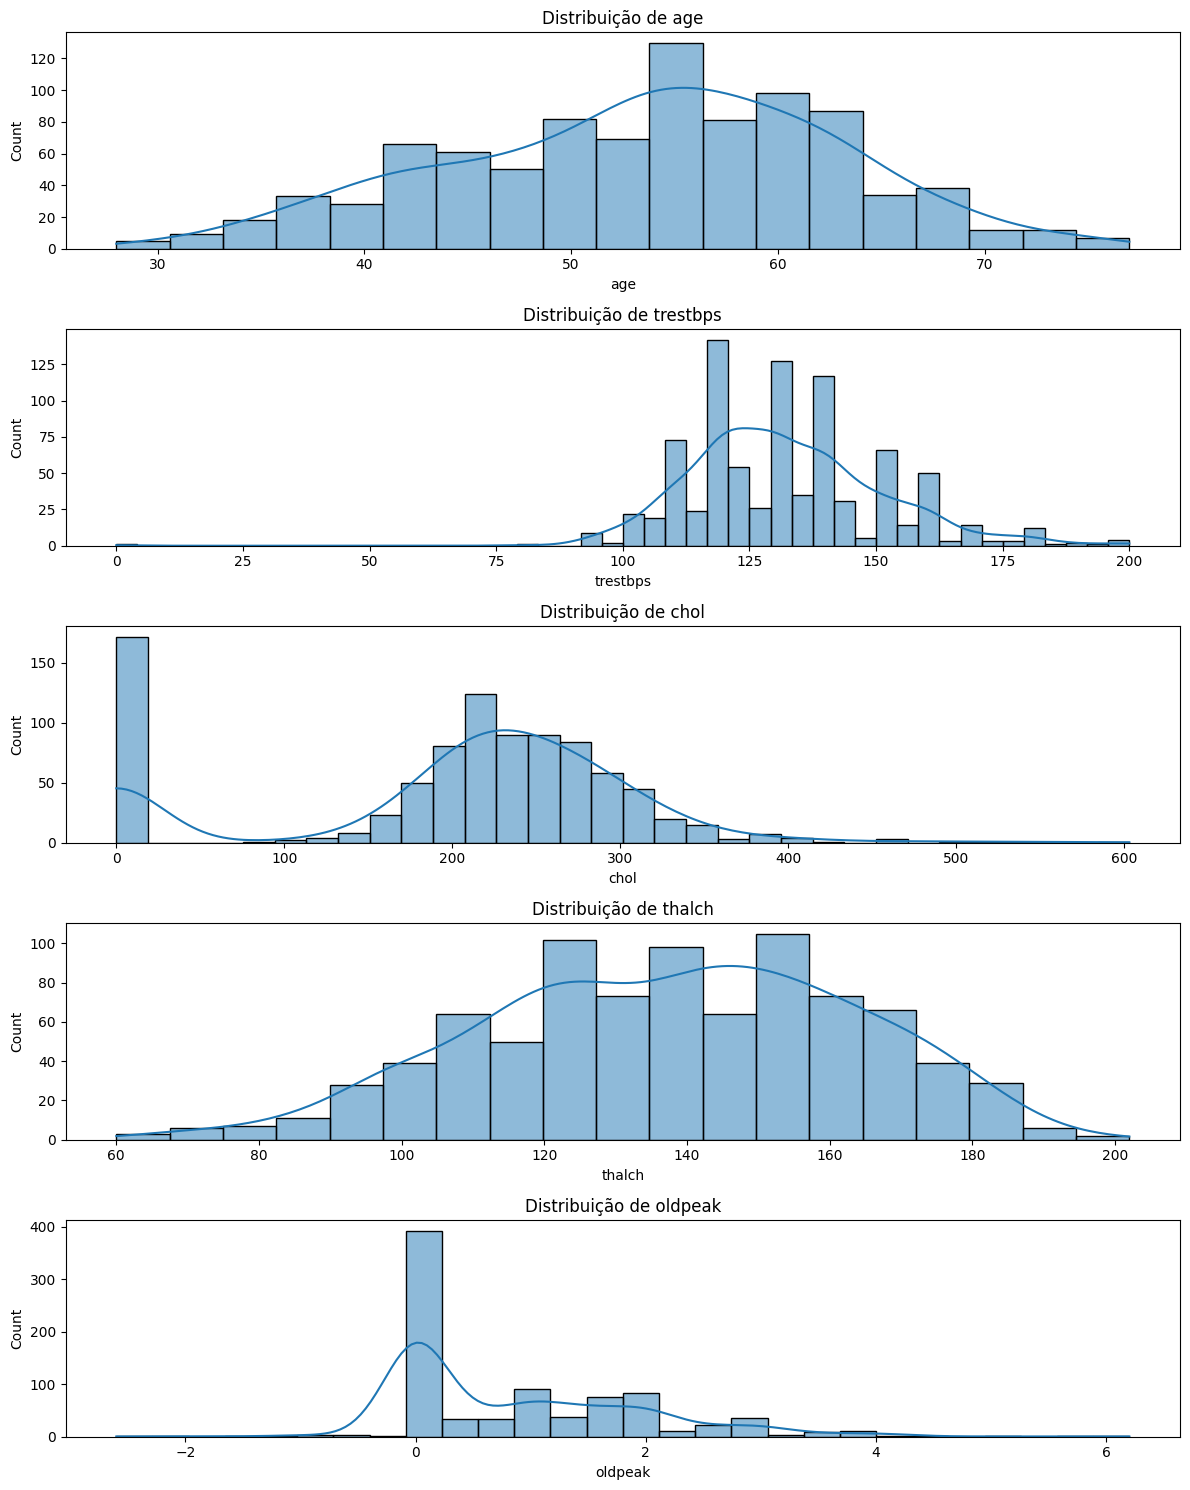

In [62]:
num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for idx, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12)

plt.tight_layout()
plt.show()

In [63]:
df[df["trestbps"] == 0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
753,754,55,Male,VA Long Beach,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,NaN,NaN,3


In [69]:
df["chol"] = df["chol"].replace(
    0,
    np.nan
)

df['chol'].count()

np.int64(718)

In [72]:
from scipy.stats import shapiro
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import normaltest
from IPython.display import display

num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

def analisar_normalidade(df, cols):
    """
    Analisa a normalidade das colunas numéricas usando testes estatísticos.
    Exibe os resultados em uma tabela para evitar truncamento.
    """
    print("="*70)
    print("ANÁLISE DE NORMALIDADE")
    print("="*70)
    
    resultados = []
    
    for col in cols:
        dados = df[col].dropna()
        
        if len(dados) < 3:
            continue
        
        # Shapiro (usa amostra se muito grande)
        amostra = dados.sample(min(5000, len(dados)), random_state=42)
        _, p_shapiro = shapiro(amostra)
        
        # D'Agostino
        _, p_normal = normaltest(dados)
        
        assimetria = skew(dados)
        curt = kurtosis(dados)
        
        # Interpretações
        shapiro_interpret = "Aproximadamente normal" if p_shapiro > 0.05 else "Rejeita normalidade"
        assimetria_interpret = (
            "Baixa" if abs(assimetria) < 0.5 
            else "Moderada" if abs(assimetria) < 1 
            else "Forte"
        )
        
        resultados.append({
            'Coluna': col,
            'Shapiro p-value': f"{p_shapiro:.6f}",
            'D\'Agostino p-value': f"{p_normal:.6f}",
            'Skewness': f"{assimetria:.4f}",
            'Kurtosis': f"{curt:.4f}",
            'Shapiro Interpretação': shapiro_interpret,
            'Assimetria Interpretação': assimetria_interpret
        })
    
    # Criar DataFrame e exibir com display
    df_resultados = pd.DataFrame(resultados)
    display(df_resultados)

# Usar a função
analisar_normalidade(df, num_cols)

ANÁLISE DE NORMALIDADE


,Coluna,Shapiro p-value,D'Agostino p-value,Skewness,Kurtosis,Shapiro Interpretação,Assimetria Interpretação
0,age,0.000023,0.000808,-0.1957,-0.3874,Rejeita normalidade,Baixa
1,trestbps,0.000000,0.000000,0.2130,2.9346,Rejeita normalidade,Baixa
2,chol,0.000000,0.000000,1.3121,4.7313,Rejeita normalidade,Forte
3,thalch,0.000019,0.000033,-0.2108,-0.4839,Rejeita normalidade,Baixa
4,oldpeak,0.000000,0.000000,1.0396,1.1135,Rejeita normalidade,Forte


# Análise de Normalidade das Variáveis Numéricas

Foram avaliadas as variáveis numéricas contínuas do dataset por meio de:

- Teste de Shapiro-Wilk  
- Teste de D’Agostino-Pearson  
- Coeficiente de Assimetria (Skewness)  
- Curtose (Kurtosis)  
- Inspeção visual dos histogramas

## Resultados

| Variável | Skewness | Kurtosis | Interpretação |
|---------|----------|----------|---------------|
| age | -0.1957 | -0.3874 | Aproximadamente normal |
| trestbps | 0.2130 | 2.9346 | Quase normal, com caudas pesadas |
| chol | 1.3121 | 4.7313 | Não normal |
| thalch | -0.2108 | -0.4839 | Aproximadamente normal |
| oldpeak | 1.0396 | 1.1135 | Não normal |

---

## Interpretação dos Testes

Os testes de Shapiro-Wilk e D’Agostino rejeitaram a hipótese nula de normalidade para todas as variáveis (p < 0.05).

Entretanto, considerando que esses testes são altamente sensíveis em amostras relativamente grandes (n = 920), pequenas violações da normalidade podem levar à rejeição mesmo quando a distribuição é visualmente próxima da normal.

Por essa razão, a interpretação foi complementada por métricas de forma (assimetria e curtose) e inspeção visual.

---

## Variáveis Aproximadamente Normais

### age
A variável apresentou:

- baixa assimetria (Skew = -0.1957)
- curtose próxima de zero
- distribuição visualmente simétrica

Embora os testes formais rejeitem normalidade estrita, a variável pode ser considerada aproximadamente normal para fins práticos.

---

### thalch
Apresentou comportamento semelhante:

- baixa assimetria (Skew = -0.2108)
- curtose próxima de zero
- distribuição aproximadamente gaussiana

Pode ser tratada como aproximadamente normal.

---

## Variável Quase Normal com Outliers

### trestbps
A distribuição apresentou:

- baixa assimetria (Skew = 0.2130)
- porém curtose elevada (2.93)

Isso sugere presença de caudas pesadas e outliers.

Pode ser considerada aproximadamente normal no centro da distribuição, mas com cautela.

---

## Variáveis Não Normais

### chol
Apresentou:

- forte assimetria positiva
- alta curtose
- cauda longa à direita

Não apresenta comportamento compatível com normalidade.

---

### oldpeak
Apresentou:

- forte assimetria positiva
- concentração elevada em zero
- cauda longa à direita

Caracteriza distribuição não normal.

---

## Implicações para análises posteriores

Com base nesses resultados:

### Variáveis adequadas para métodos paramétricos (com cautela)
- age
- thalch
- trestbps (avaliar robustez)

---

### Variáveis mais adequadas para métodos não paramétricos
- chol
- oldpeak

---

## Observação
Como a variável-alvo (`num`) possui natureza ordinal, análises de associação futuras podem se beneficiar do uso de:

- Correlação de Spearman  
- Mann-Whitney (se binarização do alvo)  
- Kruskal-Wallis (se múltiplas classes)

In [75]:
resumo=[]

for col in num_cols:

    dados = df[col].dropna()

    resumo.append({
        "Variavel":col,
        "Media":dados.mean(),
        "Mediana":dados.median(),
        "Desvio":dados.std(),
        "Min":dados.min(),
        "Q1":dados.quantile(.25),
        "Q3":dados.quantile(.75),
        "Max":dados.max(),
        "CV":dados.std()/dados.mean()
    })

pd.DataFrame(resumo)

,Variavel,Media,Mediana,Desvio,Min,Q1,Q3,Max,CV
0,age,53.510870,54.0,9.424685,28.0,47.0,60.00,77.0,0.176127
1,trestbps,132.132404,130.0,19.066070,0.0,120.0,140.00,200.0,0.144295
2,chol,246.832869,239.5,58.527062,85.0,210.0,276.75,603.0,0.237112
3,thalch,137.545665,140.0,25.926276,60.0,120.0,157.00,202.0,0.188492
4,oldpeak,0.878788,0.5,1.091226,-2.6,0.0,1.50,6.2,1.241740


# Análise Descritiva das Variáveis Numéricas

Foi realizada análise estatística descritiva das variáveis numéricas contínuas do dataset, considerando medidas de tendência central, dispersão e variabilidade relativa.

Foram avaliadas:

- Média  
- Mediana  
- Desvio padrão  
- Quartis (Q1 e Q3)  
- Valores mínimos e máximos  
- Coeficiente de variação (CV)

O coeficiente de variação foi calculado como:

:contentReference[oaicite:0]{index=0}

e permite avaliar a dispersão relativa dos dados em relação à média.

---

## age
A variável idade apresentou:

- Média = 53.51 anos  
- Mediana = 54 anos  
- Desvio padrão = 9.42  
- CV = 17.6%

A proximidade entre média e mediana indica distribuição aproximadamente simétrica, corroborando os resultados da análise de normalidade.

A variabilidade relativa é baixa a moderada, sugerindo distribuição relativamente estável em torno do valor central.

A amplitude observada (28 a 77 anos) é clinicamente plausível.

---

## trestbps
A pressão arterial em repouso apresentou:

- Média = 132.13 mmHg  
- Mediana = 130 mmHg  
- Desvio padrão = 19.07  
- CV = 14.4%

A proximidade entre média e mediana sugere tendência central estável.

Entretanto:

- valor mínimo igual a 0 é fisiologicamente implausível e pode representar erro ou dado faltante codificado;
- valor máximo de 200 sugere presença de extremos.

Apesar da baixa variabilidade relativa, a presença de outliers já havia sido sugerida pela análise de curtose.

---

## chol
A variável colesterol apresentou:

- Média = 246.83 mg/dL  
- Mediana = 239.5 mg/dL  
- Desvio padrão = 58.53  
- CV = 23.7%

A média superior à mediana reforça assimetria positiva previamente identificada.

A amplitude observada:

- mínimo = 85  
- máximo = 603

indica presença de valores extremos.

O coeficiente de variação superior ao das variáveis anteriores sugere maior dispersão relativa.

Esses resultados são coerentes com o comportamento não normal observado anteriormente.

**Observação:** valores iguais a zero em `chol`, considerados inconsistentes, foram previamente tratados e substituídos por `NaN`, não participando desta análise.

---

## thalch
A frequência cardíaca máxima apresentou:

- Média = 137.55 bpm  
- Mediana = 140 bpm  
- Desvio padrão = 25.93  
- CV = 18.8%

A proximidade entre média e mediana indica comportamento aproximadamente simétrico.

A dispersão é moderada e a amplitude (60 a 202) é plausível.

Os resultados corroboram a interpretação anterior de distribuição aproximadamente normal.

---

## oldpeak
A variável oldpeak apresentou:

- Média = 0.88  
- Mediana = 0.50  
- Desvio padrão = 1.09  
- CV = 124.2%

Foi a variável com maior variabilidade relativa.

A diferença entre média e mediana reforça forte assimetria positiva.

Além disso:

- grande concentração de valores em zero  
- cauda longa à direita  
- valores até 6.2

sugerem distribuição heterogênea e não normal.

O coeficiente de variação elevado reforça instabilidade e alta dispersão.

O valor mínimo negativo (-2.6) merece investigação adicional para verificar plausibilidade clínica ou possíveis convenções de codificação.

---

# Síntese Geral

## Variáveis com maior estabilidade
As variáveis:

- age  
- thalch  

apresentaram:

- média e mediana muito próximas  
- baixa assimetria  
- menor dispersão relativa

sugerindo comportamento mais estável.

---

## Variáveis com maior dispersão ou extremos
As variáveis:

- trestbps  
- chol  
- oldpeak

apresentaram maior presença de:

- outliers  
- assimetria  
- caudas pesadas  
- dispersão relativa elevada

com destaque para `oldpeak`, que apresentou a maior variabilidade do conjunto.

---

## Conclusão
A análise descritiva corroborou os achados da análise de normalidade:

- `age` e `thalch` mostraram comportamento aproximadamente normal e estável;

- `trestbps` apresentou tendência central estável, porém com extremos;

- `chol` e `oldpeak` reforçaram comportamento não normal e maior heterogeneidade.

Esses resultados têm implicações para etapas posteriores de modelagem e para escolha de métodos estatísticos apropriados.

In [ ]:
from scipy.stats import spearmanr

for col in num_cols:

    rho,p = spearmanr(
        df[col],
        df["num"],
        nan_policy='omit'
    )

    print(
        col,
        rho,
        p
    )

age 0.3471841296135375 1.872271109920102e-27
trestbps 0.1268052959081104 0.00019111099700861104
chol 0.11276185900747233 0.0024789085003521258
thalch -0.398359531306959 2.8143425639337157e-34
oldpeak 0.4342732649332619 8.908109449686758e-41
